<a href="https://colab.research.google.com/github/anajulidorio/inteligencia-artificial/blob/main/l%C3%B3gica_fuzzy_peso_e_altura.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -U scikit-fuzzy

In [ ]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np

In [ ]:
peso = ctrl.Antecedent(np.arange(20,120,1), 'peso')
altura = ctrl.Antecedent(np.arange(1.2, 2, 0.1), 'altura') ##variáveis de entrada e seus universos

In [ ]:
tamanho = ctrl.Consequent(np.arange(0, 1, 0.1), 'tamanho') ##saída e seu universo

In [ ]:
# criando os conjuntos fuzzy e as funções de pertinência para entrada peso

peso['baixo'] = fuzz.trimf(peso.universe, [20, 45, 70])
peso['medio'] = fuzz.trimf(peso.universe, [55, 75, 95])
peso['alto'] = fuzz.trimf(peso.universe, [80, 100, 120])

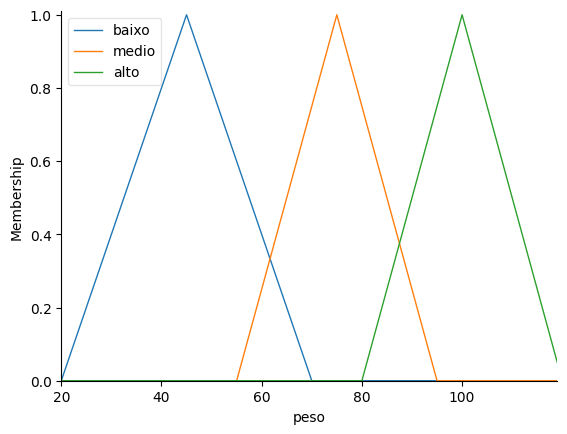

In [ ]:
#visualizando o peso

peso.view()

In [ ]:
# criando os conj. fuzzy e as funções de pertinência para entrada altura

altura['baixa'] = fuzz.trapmf(altura.universe, [1.2, 1.2, 1.4, 1.5])
altura['media'] = fuzz.trapmf(altura.universe, [1.4, 1.5, 1.6, 1.7])
altura['alta'] = fuzz.trapmf(altura.universe, [1.68, 1.7, 2, 2])

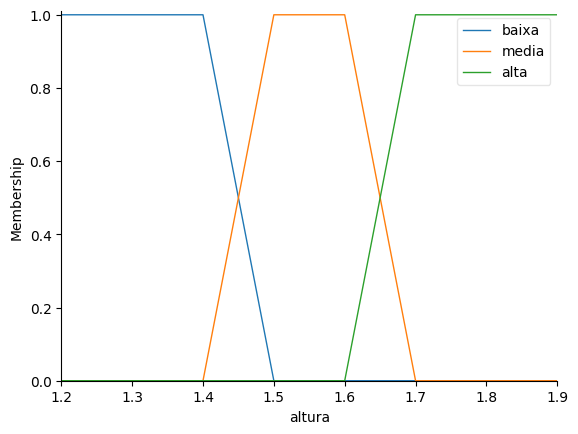

In [ ]:
altura.view()

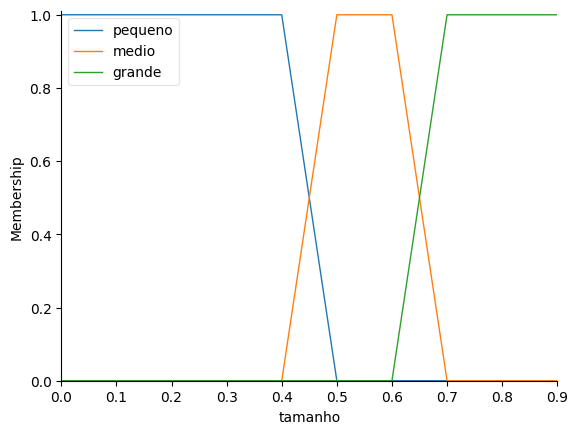

In [ ]:
# criando os conjuntos fuzzy e suas funções de pertinência para saída tamanho

tamanho['pequeno'] = fuzz.trapmf(tamanho.universe, [0, 0, 0.4, 0.5])
tamanho['medio'] = fuzz.trapmf(tamanho.universe, [0.4, 0.5, 0.6, 0.7])
tamanho['grande'] = fuzz.trapmf(tamanho.universe, [0.65, 0.7, 1, 1])

tamanho.view()

In [ ]:
# regra 1 - SE peso é baixo ENTÃO tamanho é pequeno

regra1 = ctrl.Rule(peso['baixo'], tamanho['pequeno'])

In [ ]:
# regra 2 - SE altura é mediana OU peso é médio ENTÃO tamanho é médio

regra2 = ctrl.Rule(altura['media'] | peso['medio'], tamanho['medio'])

In [ ]:
# regra 3 - SE altura é alta E peso é alto ENTÃO tamanho é grande

regra3 = ctrl.Rule(altura['alta'] & peso['alto'], tamanho['grande'])

In [ ]:
# criando controlador fuzzy com as regras - cria a inteligencia
fuzzy_ctrl = ctrl.ControlSystem([regra1, regra2, regra3])

# criando motor de inferência - coloca dentro de um motor pra funcionar
engine = ctrl.ControlSystemSimulation(fuzzy_ctrl)

0.35241138659320514


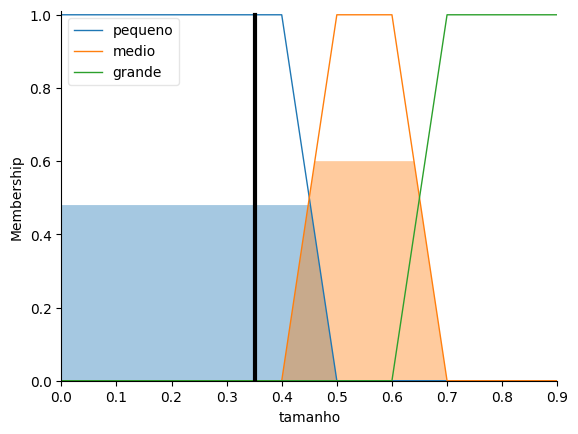

In [ ]:
# passa as predições dos modelos
engine.input['peso'] = 58
engine.input['altura'] = 1.64

# calcula a saida do sistema de controle fuzzy
engine.compute()

#retorna o valor crisp e o gráfico
print(engine.output['tamanho'])
tamanho.view(sim=engine)